In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

df = pd.read_csv(
    PROJECT_ROOT
    / "data"
    / "processed"
    / "regime_model_dataset.csv",
    parse_dates=["Date"],
)

print(df.shape)
print(df["Date"].min(), df["Date"].max())

(1171, 72)
2016-01-31 00:00:00 2025-10-31 00:00:00


In [2]:
baseline_features = [
    "mom_1m",
    "mom_3m",
    "mom_6m",
    "mom_12m",
    "vol_3m",
    "vol_6m",
    "vol_12m",
    "drawdown_12m",

    "spy_mom_1m",
    "spy_mom_3m",
    "spy_mom_6m",
    "spy_mom_12m",
    "spy_vol_3m",
    "spy_vol_6m",
    "spy_vol_12m",
    "spy_drawdown_12m",

    "DGS10",
    "DGS2",
    "DFF",
    "VIXCLS",
    "yield_spread_10y_2y",
    "DGS10_change_1m",
    "DGS2_change_1m",
    "DFF_change_1m",
    "VIXCLS_change_1m",
    "yield_spread_10y_2y_change_1m",
]

advanced_market_features = [
    "beta_6m",
    "beta_12m",
    "corr_spy_6m",
    "corr_spy_12m",
    "mom_3m_rank_pct",
    "mom_6m_rank_pct",
    "mom_12m_rank_pct",
    "vol_3m_rank_pct",
    "vol_6m_rank_pct",
    "vol_12m_rank_pct",
    "sector_return_dispersion",
]

new_macro_features = [
    "BAA10Y",
    "BAA10Y_change_1m",
    "DCOILWTICO",
    "DCOILWTICO_change_1m",
    "CPI_YOY_lag1",
    "CPI_YOY_change_1m_lag1",
    "UNRATE_lag1",
    "UNRATE_change_1m_lag1",
]

regime_features = [
    "high_vix_regime",
    "inverted_yield_curve",
    "rising_rate_regime",
    "credit_stress_regime",
    "rising_inflation_regime",
    "rising_unemployment_regime",
    "momentum_x_high_vix",
    "beta_x_high_vix",
    "momentum_x_inverted_curve",
    "momentum_x_credit_stress",
]

regime_aware_features = (
    baseline_features
    + advanced_market_features
    + new_macro_features
    + regime_features
)

In [3]:
train = df[
    df["Date"] <= "2022-12-31"
].copy()

test = df[
    df["Date"] >= "2023-01-01"
].copy()

print("Training observations:", len(train))
print("Test observations:", len(test))
print("Test months:", test["Date"].nunique())
print(
    "Test period:",
    test["Date"].min(),
    "to",
    test["Date"].max(),
)

Training observations: 831
Test observations: 340
Test months: 34
Test period: 2023-01-31 00:00:00 to 2025-10-31 00:00:00


In [4]:
X_train = train[
    regime_aware_features + ["Ticker"]
]

y_train = train["next_excess_return"]

X_test = test[
    regime_aware_features + ["Ticker"]
]


preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            regime_aware_features,
        ),
        (
            "ticker",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore",
                sparse_output=False,
            ),
            ["Ticker"],
        ),
    ]
)

regime_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=1.0)),
])

regime_model.fit(X_train, y_train)

test["regime_prediction"] = (
    regime_model.predict(X_test)
)

In [5]:
portfolio_rows = []

for date, month in test.groupby("Date"):

    # -------------------------
    # 12-month momentum
    # -------------------------

    momentum_top3 = (
        month
        .sort_values(
            "mom_12m",
            ascending=False,
        )
        .head(3)
    )

    portfolio_rows.append({
        "Date": date,
        "strategy": "12m_momentum",
        "holdings": tuple(
            momentum_top3["Ticker"].tolist()
        ),
        "gross_return":
            momentum_top3[
                "next_etf_return"
            ].mean(),
        "spy_return":
            momentum_top3[
                "next_spy_return"
            ].iloc[0],
    })

    # -------------------------
    # Regime-aware ML
    # -------------------------

    ml_top3 = (
        month
        .sort_values(
            "regime_prediction",
            ascending=False,
        )
        .head(3)
    )

    portfolio_rows.append({
        "Date": date,
        "strategy": "regime_aware_ml",
        "holdings": tuple(
            ml_top3["Ticker"].tolist()
        ),
        "gross_return":
            ml_top3[
                "next_etf_return"
            ].mean(),
        "spy_return":
            ml_top3[
                "next_spy_return"
            ].iloc[0],
    })


portfolios = pd.DataFrame(portfolio_rows)

portfolios.head()

,Date,strategy,holdings,gross_return,spy_return
0,2023-01-31,12m_momentum,"(XLE, XLV, XLI)",-0.041481,-0.025143
1,2023-01-31,regime_aware_ml,"(XLY, XLK, XLI)",-0.008591,-0.025143
2,2023-02-28,12m_momentum,"(XLE, XLI, XLB)",-0.001255,0.037078
3,2023-02-28,regime_aware_ml,"(XLY, XLB, XLK)",0.043063,0.037078
4,2023-03-31,12m_momentum,"(XLE, XLP, XLI)",0.017549,0.015975


In [6]:
def calculate_turnover(holdings_series):

    turnovers = []
    previous_weights = None

    for holdings in holdings_series:

        current_weights = {
            ticker: 1 / len(holdings)
            for ticker in holdings
        }

        # Initial portfolio formation
        if previous_weights is None:
            turnover = 1.0

        else:
            all_tickers = (
                set(previous_weights)
                | set(current_weights)
            )

            turnover = 0.5 * sum(
                abs(
                    current_weights.get(ticker, 0)
                    - previous_weights.get(ticker, 0)
                )
                for ticker in all_tickers
            )

        turnovers.append(turnover)

        previous_weights = current_weights

    return turnovers

In [7]:
portfolios = (
    portfolios
    .sort_values(["strategy", "Date"])
    .reset_index(drop=True)
)

portfolios["turnover"] = (
    portfolios
    .groupby("strategy")["holdings"]
    .transform(calculate_turnover)
)

In [8]:
turnover_summary = (
    portfolios
    .groupby("strategy")["turnover"]
    .agg(
        mean_turnover="mean",
        median_turnover="median",
        max_turnover="max",
        total_turnover="sum",
    )
)

turnover_summary

,mean_turnover,median_turnover,max_turnover,total_turnover
strategy,,,,
12m_momentum,0.235294,0.333333,1.0,8.000000
regime_aware_ml,0.333333,0.333333,1.0,11.333333


In [9]:
transaction_costs = {
    "0_bps": 0.0000,
    "10_bps": 0.0010,
    "25_bps": 0.0025,
}

for label, cost_rate in transaction_costs.items():

    portfolios[f"net_return_{label}"] = (
        portfolios["gross_return"]
        - portfolios["turnover"] * cost_rate
    )

In [10]:
def performance_metrics(returns):

    returns = returns.dropna()

    growth = (1 + returns).cumprod()

    cumulative_return = (
        growth.iloc[-1] - 1
    )

    annualized_return = (
        growth.iloc[-1]
        ** (12 / len(returns))
        - 1
    )

    annualized_volatility = (
        returns.std() * np.sqrt(12)
    )

    sharpe_like = (
        annualized_return
        / annualized_volatility
        if annualized_volatility > 0
        else np.nan
    )

    running_peak = growth.cummax()

    drawdown = (
        growth / running_peak - 1
    )

    max_drawdown = drawdown.min()

    return {
        "cumulative_return":
            cumulative_return,
        "annualized_return":
            annualized_return,
        "annualized_volatility":
            annualized_volatility,
        "sharpe_like":
            sharpe_like,
        "max_drawdown":
            max_drawdown,
    }

In [11]:
cost_results = []

for strategy, strategy_df in portfolios.groupby(
    "strategy"
):

    strategy_df = (
        strategy_df
        .sort_values("Date")
    )

    for label in transaction_costs:

        metrics = performance_metrics(
            strategy_df[
                f"net_return_{label}"
            ]
        )

        cost_results.append({
            "strategy": strategy,
            "transaction_cost": label,
            **metrics,
        })


cost_summary = pd.DataFrame(
    cost_results
)

cost_summary

,strategy,transaction_cost,cumulative_return,annualized_return,annualized_volatility,sharpe_like,max_drawdown
0,12m_momentum,0_bps,0.477298,0.147657,0.133360,1.107205,-0.088984
1,12m_momentum,10_bps,0.465674,0.144462,0.133316,1.083606,-0.089581
2,12m_momentum,25_bps,0.448401,0.139684,0.133258,1.048217,-0.090476
3,regime_aware_ml,0_bps,0.566843,0.171744,0.144931,1.184999,-0.114039
4,regime_aware_ml,10_bps,0.549235,0.167079,0.145206,1.150637,-0.117382
5,regime_aware_ml,25_bps,0.523176,0.160112,0.145628,1.099464,-0.122377


In [12]:
spy_monthly = (
    portfolios[
        ["Date", "spy_return"]
    ]
    .drop_duplicates(subset="Date")
    .sort_values("Date")
)

spy_metrics = performance_metrics(
    spy_monthly["spy_return"]
)

pd.Series(
    spy_metrics,
    name="SPY",
)

cumulative_return        0.743832
annualized_return        0.216850
annualized_volatility    0.119602
sharpe_like              1.813094
max_drawdown            -0.083258
Name: SPY, dtype: float64

In [13]:
gross_strategy_results = (
    cost_summary[
        cost_summary[
            "transaction_cost"
        ] == "0_bps"
    ]
    .copy()
)

spy_row = pd.DataFrame([
    {
        "strategy": "SPY",
        "transaction_cost": "0_bps",
        **spy_metrics,
    }
])

final_performance_table = pd.concat(
    [
        gross_strategy_results,
        spy_row,
    ],
    ignore_index=True,
)

final_performance_table

,strategy,transaction_cost,cumulative_return,annualized_return,annualized_volatility,sharpe_like,max_drawdown
0,12m_momentum,0_bps,0.477298,0.147657,0.133360,1.107205,-0.088984
1,regime_aware_ml,0_bps,0.566843,0.171744,0.144931,1.184999,-0.114039
2,SPY,0_bps,0.743832,0.216850,0.119602,1.813094,-0.083258


In [14]:
growth_data = []

for strategy, strategy_df in portfolios.groupby(
    "strategy"
):

    strategy_df = (
        strategy_df
        .sort_values("Date")
        .copy()
    )

    strategy_df["growth"] = (
        1
        + strategy_df["gross_return"]
    ).cumprod()

    growth_data.append(
        strategy_df[
            ["Date", "strategy", "growth"]
        ]
    )


spy_plot = spy_monthly.copy()

spy_plot["growth"] = (
    1 + spy_plot["spy_return"]
).cumprod()

spy_plot["strategy"] = "SPY"

spy_plot = spy_plot[
    ["Date", "strategy", "growth"]
]


growth_df = pd.concat(
    growth_data + [spy_plot],
    ignore_index=True,
)

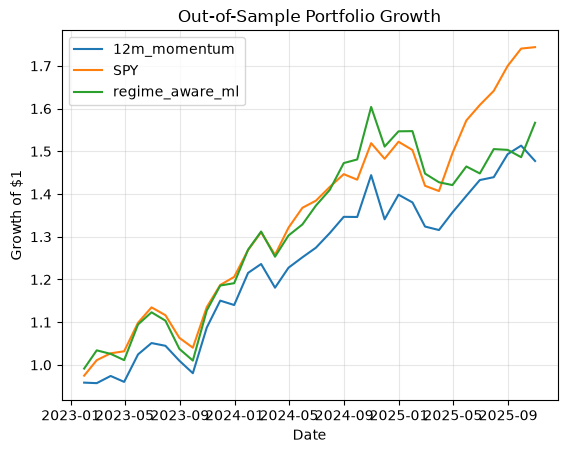

In [15]:
for strategy, group in growth_df.groupby(
    "strategy"
):
    plt.plot(
        group["Date"],
        group["growth"],
        label=strategy,
    )

plt.title(
    "Out-of-Sample Portfolio Growth"
)
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Final out-of-sample conclusion

On the held-out 2023–2025 test period, the regime-aware Ridge strategy
outperformed the simple 12-month momentum strategy in both cumulative
return and risk-adjusted performance.

The regime-aware strategy generated a 56.7% cumulative return compared
with 47.7% for the momentum benchmark. Its advantage remained under
transaction-cost assumptions of 10 and 25 basis points per unit of
portfolio turnover.

However, neither active strategy outperformed SPY. SPY generated a
74.4% cumulative return over the same test period, with higher annualized
return, lower volatility, and stronger risk-adjusted performance.

These results suggest that the additional macroeconomic and regime-aware
features improved sector ranking relative to a simple momentum heuristic,
but did not generate sufficient predictive value to outperform the broad
market benchmark during the held-out period.

The 2023–2025 test data were not used for model selection or
hyperparameter tuning.